In [4]:
from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model
llm= ChatOpenAI()

In [1]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? · Hugging Face',
   'content': '# What is LangGraph ? `LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? ## When should I use LangGraph ? `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application involves a series of steps that need to be orchestrated in a specific way, with decisions being made at each junction point, **LangGraph provides the structur

In [15]:
def multiply(a:int,b:int)->int:
    """Multiplies a and b
    Arg:s:
        a (int): first number
        b (int): second number
    
    Returns:
        int: output int
    """
    return a*b

In [16]:
tools=[tool,multiply]

In [17]:
llm_with_tools=llm.bind_tools(tools)

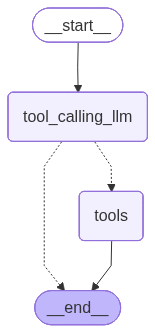

In [18]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import  tools_condition
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]

#Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
                              tools_condition)

builder.add_edge("tools",END)

#Compile the graph
graph= builder.compile()

from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))


In [10]:
response=graph.invoke({"messages":"What is the recent AI news ?"})

In [11]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/ai-arms-race-accelerates-with-new-models-from-openai-deepseek-and-anthropic/", "title": "AI Arms Race Accelerates With New Models from OpenAI, DeepSeek and Anthropic - CNET", "score": 0.94891727, "published_date": "Fri, 24 Apr 2026 19:48:00 GMT", "content": "The newest offerings, DeepSeek\'s V4 Flash and V4 Pro AI models, are focused on reasoning and agentic AI tasks, with the Chinese company\'s latest work using a Hybrid Attention Architecture. DeepSeek said\\") this allows its models to keep query histories in mind even over a lengthy series of prompts. V4 also allows longer documents or code to be used as prompts, and the company said it has made architectural and optimization improvements. The models can also be deployed on cheaper hardware than other AI, which could lower costs for companies that want to use them. [...] The co

In [12]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_vV5KSr5ROR1VJnU3iYSOK3mf)
 Call ID: call_vV5KSr5ROR1VJnU3iYSOK3mf
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/ai-arms-race-accelerates-with-new-models-from-openai-deepseek-and-anthropic/", "title": "AI Arms Race Accelerates With New Models from OpenAI, DeepSeek and Anthropic - CNET", "score": 0.94891727, "published_date": "Fri, 24 Apr 2026 19:48:00 GMT", "content": "The newest offerings, DeepSeek's V4 Flash and V4 Pro AI models, are focused on reasoning and agentic AI tasks, wit

In [19]:
response=graph.invoke({"messages":"What is 2 multiplied by 3?"})

In [22]:
response

{'messages': [HumanMessage(content='What is 2 multiplied by 3?', additional_kwargs={}, response_metadata={}, id='5c0b4523-d3d9-4725-a019-4fe64c358e52'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1304, 'total_tokens': 1321, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DYObhBmE56Z6lIwpVa9aGketqmTt1', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dc2d3-2ae0-7003-8f89-808b20874a4e-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_vxZjPMwWGOveUJ3wOCLtsHyh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1304, 'output_tokens': 17, 't

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_vxZjPMwWGOveUJ3wOCLtsHyh)
 Call ID: call_vxZjPMwWGOveUJ3wOCLtsHyh
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
